# Figure 2 Replication: Effect of Model Instructions on Truth Direction Emergence

This notebook replicates **Figure 2** from *Testing the Limits of Truth Directions in LLMs* (Poulis et al., 2026) on **DeepSeek-R1-Distill-8B** ($L=32, d_{\text{model}}=4096$).

---

## 1. Theoretical Motivation & Mapping
In Poulis et al. (2026), **Figure 2** investigates how explicit instructions alter the depthwise emergence and geometric alignment of truth directions across transformer layers.

In this pipeline:
- **No-Prompt Baseline (Plaintext)**: Raw tokenized factual and arithmetic statements without instruction wrappers or chat templates (represented by **solid lines**).
- **Ask-Correct Condition**: Mapped to **Chain-of-Thought (CoT Zero-Shot / Sentence-Based CoT)** reasoning (represented by **bold dashed lines**).

### Benchmark Evaluation Hierarchy:
- **Arithmetic Tasks**: $A_1$ (1-operation), $A_2$ (2-operation), $A_3$ (3-operation).
- **Factual & Compositional Tasks**: $F_0$ (atomic facts), $F_1$ (explicit negations), $F_2$ (binary conjunctions), $F_3$ (2-item cardinality), $F_4$ (5-item cardinality), $F_5$ (dual-predicate set comparison).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load in-domain benchmark data
csv_path = "results_database.csv"
df = pd.read_csv(csv_path)
model_name = "deepseek-r1-distill-8b"

in_domain = df[(df["train_task"] == df["test_task"]) & (df["model"] == model_name)].copy()
print(f"Loaded {len(in_domain)} in-domain rows across conditions: {in_domain['train_condition'].unique()}")

# Define consistent style map
STYLE_MAP = {
    "A1": {"color": "#1f77b4", "marker": "*", "label": "A1: 1-Op Arithmetic"},
    "A2": {"color": "#ff7f0e", "marker": "X", "label": "A2: 2-Op Arithmetic"},
    "A3": {"color": "#17becf", "marker": "h", "label": "A3: 3-Op Arithmetic"},
    "F0": {"color": "#2ca02c", "marker": "o", "label": "F0: Atomic Facts"},
    "F1": {"color": "#9467bd", "marker": "s", "label": "F1: Negations"},
    "F2": {"color": "#8c564b", "marker": "^", "label": "F2: Conjunctions"},
    "F3": {"color": "#e377c2", "marker": "D", "label": "F3: 2-Count Cardinality"},
    "F4": {"color": "#d62728", "marker": "v", "label": "F4: 5-Count Cardinality"},
    "F5": {"color": "#7f7f7f", "marker": "P", "label": "F5: Set Comparison"},
}

Loaded 1188 in-domain rows across conditions: <StringArray>
['cot-zero-shot', 'no-prompt-chat-template', 'no-prompt',
 'sentence-based-CoT']
Length: 4, dtype: str


## 2. Empirical Benchmark Summary Table: Peak AUROC & Optimal Layer ($L^*$)

In [3]:
# Compute peak AUROC and optimal layer index for each task and condition
tasks = ["A1", "A2", "A3", "F0", "F1", "F2", "F3", "F4", "F5"]
conditions = ["no-prompt", "cot-zero-shot", "sentence-based-CoT"]

summary_rows = []
for task in tasks:
    row = {"Task": task, "Description": STYLE_MAP[task]["label"].split(": ")[1]}
    for cond in conditions:
        sub = in_domain[(in_domain["train_task"] == task) & (in_domain["train_condition"] == cond)]
        if len(sub) > 0:
            best_row = sub.loc[sub["auroc"].idxmax()]
            row[f"{cond} (Peak AUROC)"] = f"{best_row['auroc']:.4f} (L_{int(best_row['layer'])})"
        else:
            row[f"{cond} (Peak AUROC)"] = "N/A"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_markdown(index=False))
summary_df

| Task   | Description         | no-prompt (Peak AUROC)   | cot-zero-shot (Peak AUROC)   | sentence-based-CoT (Peak AUROC)   |
|:-------|:--------------------|:-------------------------|:-----------------------------|:----------------------------------|
| A1     | 1-Op Arithmetic     | 0.9330 (L_31)            | 0.9943 (L_12)                | 0.9988 (L_19)                     |
| A2     | 2-Op Arithmetic     | 0.6920 (L_30)            | 1.0000 (L_14)                | 1.0000 (L_14)                     |
| A3     | 3-Op Arithmetic     | 0.6323 (L_12)            | 1.0000 (L_13)                | 1.0000 (L_26)                     |
| F0     | Atomic Facts        | 0.9896 (L_13)            | 0.9840 (L_32)                | 0.9696 (L_27)                     |
| F1     | Negations           | 0.9936 (L_26)            | 0.9896 (L_22)                | 0.9801 (L_32)                     |
| F2     | Conjunctions        | 0.9892 (L_32)            | 0.9590 (L_15)                | 0.9841 (L_28)       

,Task,Description,no-prompt (Peak AUROC),cot-zero-shot (Peak AUROC),sentence-based-CoT (Peak AUROC)
0,A1,1-Op Arithmetic,0.9330 (L_31),0.9943 (L_12),0.9988 (L_19)
1,A2,2-Op Arithmetic,0.6920 (L_30),1.0000 (L_14),1.0000 (L_14)
2,A3,3-Op Arithmetic,0.6323 (L_12),1.0000 (L_13),1.0000 (L_26)
3,F0,Atomic Facts,0.9896 (L_13),0.9840 (L_32),0.9696 (L_27)
4,F1,Negations,0.9936 (L_26),0.9896 (L_22),0.9801 (L_32)
5,F2,Conjunctions,0.9892 (L_32),0.9590 (L_15),0.9841 (L_28)
6,F3,2-Count Cardinality,0.9445 (L_32),0.9780 (L_32),0.9586 (L_28)
7,F4,5-Count Cardinality,0.8610 (L_32),0.9678 (L_19),0.9637 (L_30)
8,F5,Set Comparison,0.7691 (L_26),0.9740 (L_21),0.9745 (L_31)


## 3. Canonical Figure 2: 2-Panel Layout (Poulis et al. Replication)
Comparing No-Prompt Baseline (Solid lines) against CoT Zero-Shot [Ask-Correct] (Bold dashed lines).

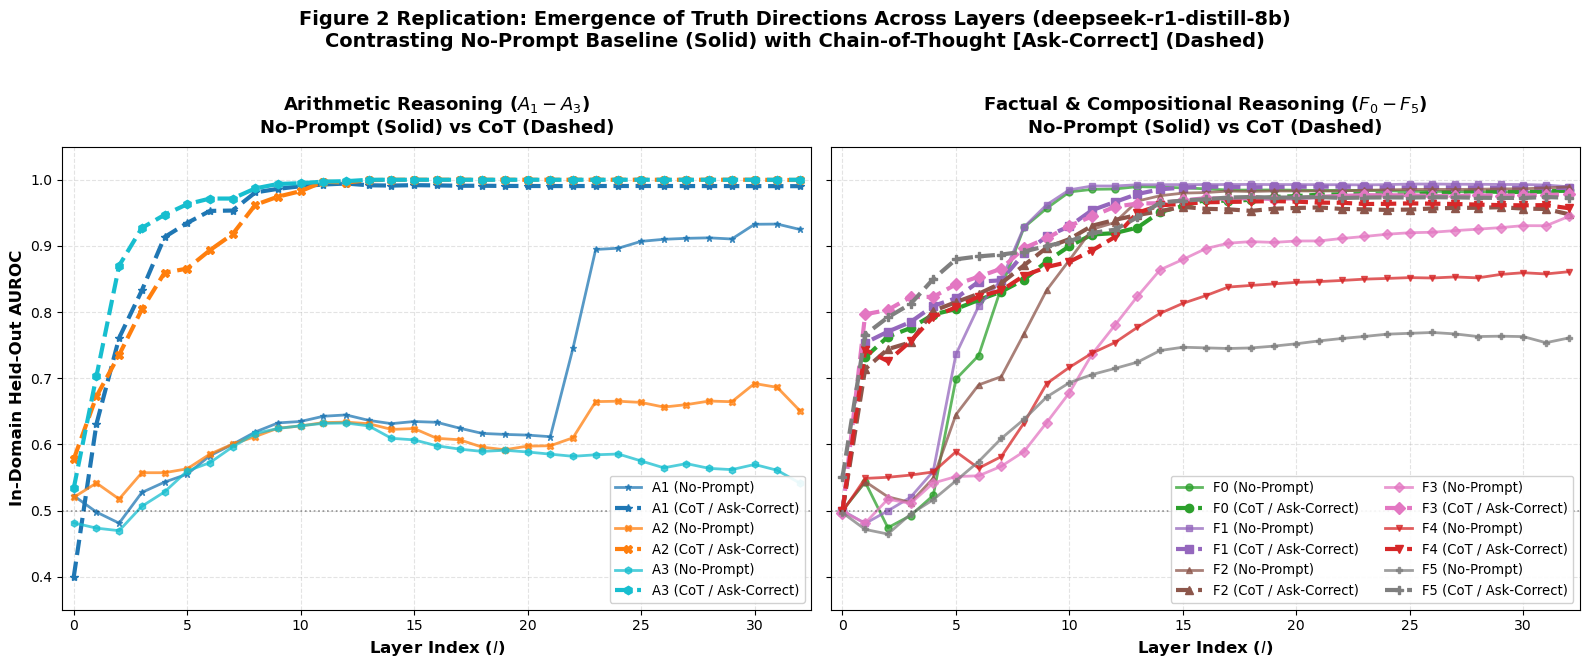

In [4]:
fig, (ax_arith, ax_fact) = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)

arith_tasks = ["A1", "A2", "A3"]
fact_tasks = ["F0", "F1", "F2", "F3", "F4", "F5"]

plain_df = in_domain[(in_domain["train_condition"] == "no-prompt")]
cot_df = in_domain[(in_domain["train_condition"] == "cot-zero-shot")]

# Left Panel: Arithmetic Tasks
for task in arith_tasks:
    cfg = STYLE_MAP[task]
    sub_p = plain_df[plain_df["train_task"] == task].sort_values("layer")
    if len(sub_p) > 0:
        ax_arith.plot(sub_p["layer"], sub_p["auroc"], color=cfg["color"], linestyle="-",
                      linewidth=2.0, alpha=0.75, marker=cfg["marker"], markersize=5, label=f"{task} (No-Prompt)")
    sub_c = cot_df[cot_df["train_task"] == task].sort_values("layer")
    if len(sub_c) > 0:
        ax_arith.plot(sub_c["layer"], sub_c["auroc"], color=cfg["color"], linestyle="--",
                      linewidth=3.0, alpha=1.0, marker=cfg["marker"], markersize=6, label=f"{task} (CoT / Ask-Correct)")

ax_arith.axhline(0.5, color="black", linestyle=":", alpha=0.4, linewidth=1.2)
ax_arith.set_xlabel("Layer Index ($l$)", fontsize=12, fontweight="bold")
ax_arith.set_ylabel("In-Domain Held-Out AUROC", fontsize=12, fontweight="bold")
ax_arith.set_title("Arithmetic Reasoning ($A_1 - A_3$)\nNo-Prompt (Solid) vs CoT (Dashed)", fontsize=13, fontweight="bold", pad=10)
ax_arith.set_ylim(0.35, 1.05)
ax_arith.set_xlim(-0.5, 32.5)
ax_arith.grid(True, linestyle="--", alpha=0.35)
ax_arith.legend(loc="lower right", fontsize=9.5, framealpha=0.9)

# Right Panel: Factual Tasks
for task in fact_tasks:
    cfg = STYLE_MAP[task]
    sub_p = plain_df[plain_df["train_task"] == task].sort_values("layer")
    if len(sub_p) > 0:
        ax_fact.plot(sub_p["layer"], sub_p["auroc"], color=cfg["color"], linestyle="-",
                     linewidth=2.0, alpha=0.75, marker=cfg["marker"], markersize=5, label=f"{task} (No-Prompt)")
    sub_c = cot_df[cot_df["train_task"] == task].sort_values("layer")
    if len(sub_c) > 0:
        ax_fact.plot(sub_c["layer"], sub_c["auroc"], color=cfg["color"], linestyle="--",
                     linewidth=3.0, alpha=1.0, marker=cfg["marker"], markersize=6, label=f"{task} (CoT / Ask-Correct)")

ax_fact.axhline(0.5, color="black", linestyle=":", alpha=0.4, linewidth=1.2)
ax_fact.set_xlabel("Layer Index ($l$)", fontsize=12, fontweight="bold")
ax_fact.set_title("Factual & Compositional Reasoning ($F_0 - F_5$)\nNo-Prompt (Solid) vs CoT (Dashed)", fontsize=13, fontweight="bold", pad=10)
ax_fact.set_ylim(0.35, 1.05)
ax_fact.set_xlim(-0.5, 32.5)
ax_fact.grid(True, linestyle="--", alpha=0.35)
ax_fact.legend(loc="lower right", fontsize=9.5, framealpha=0.9, ncol=2)

plt.suptitle(f"Figure 2 Replication: Emergence of Truth Directions Across Layers ({model_name})\nContrasting No-Prompt Baseline (Solid) with Chain-of-Thought [Ask-Correct] (Dashed)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/figure_2_poulis_replication.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Detailed $3 \times 3$ Per-Task Grid: Depthwise Truth Probing Trajectories
Directly contrasting all 3 conditions for each task in isolation.

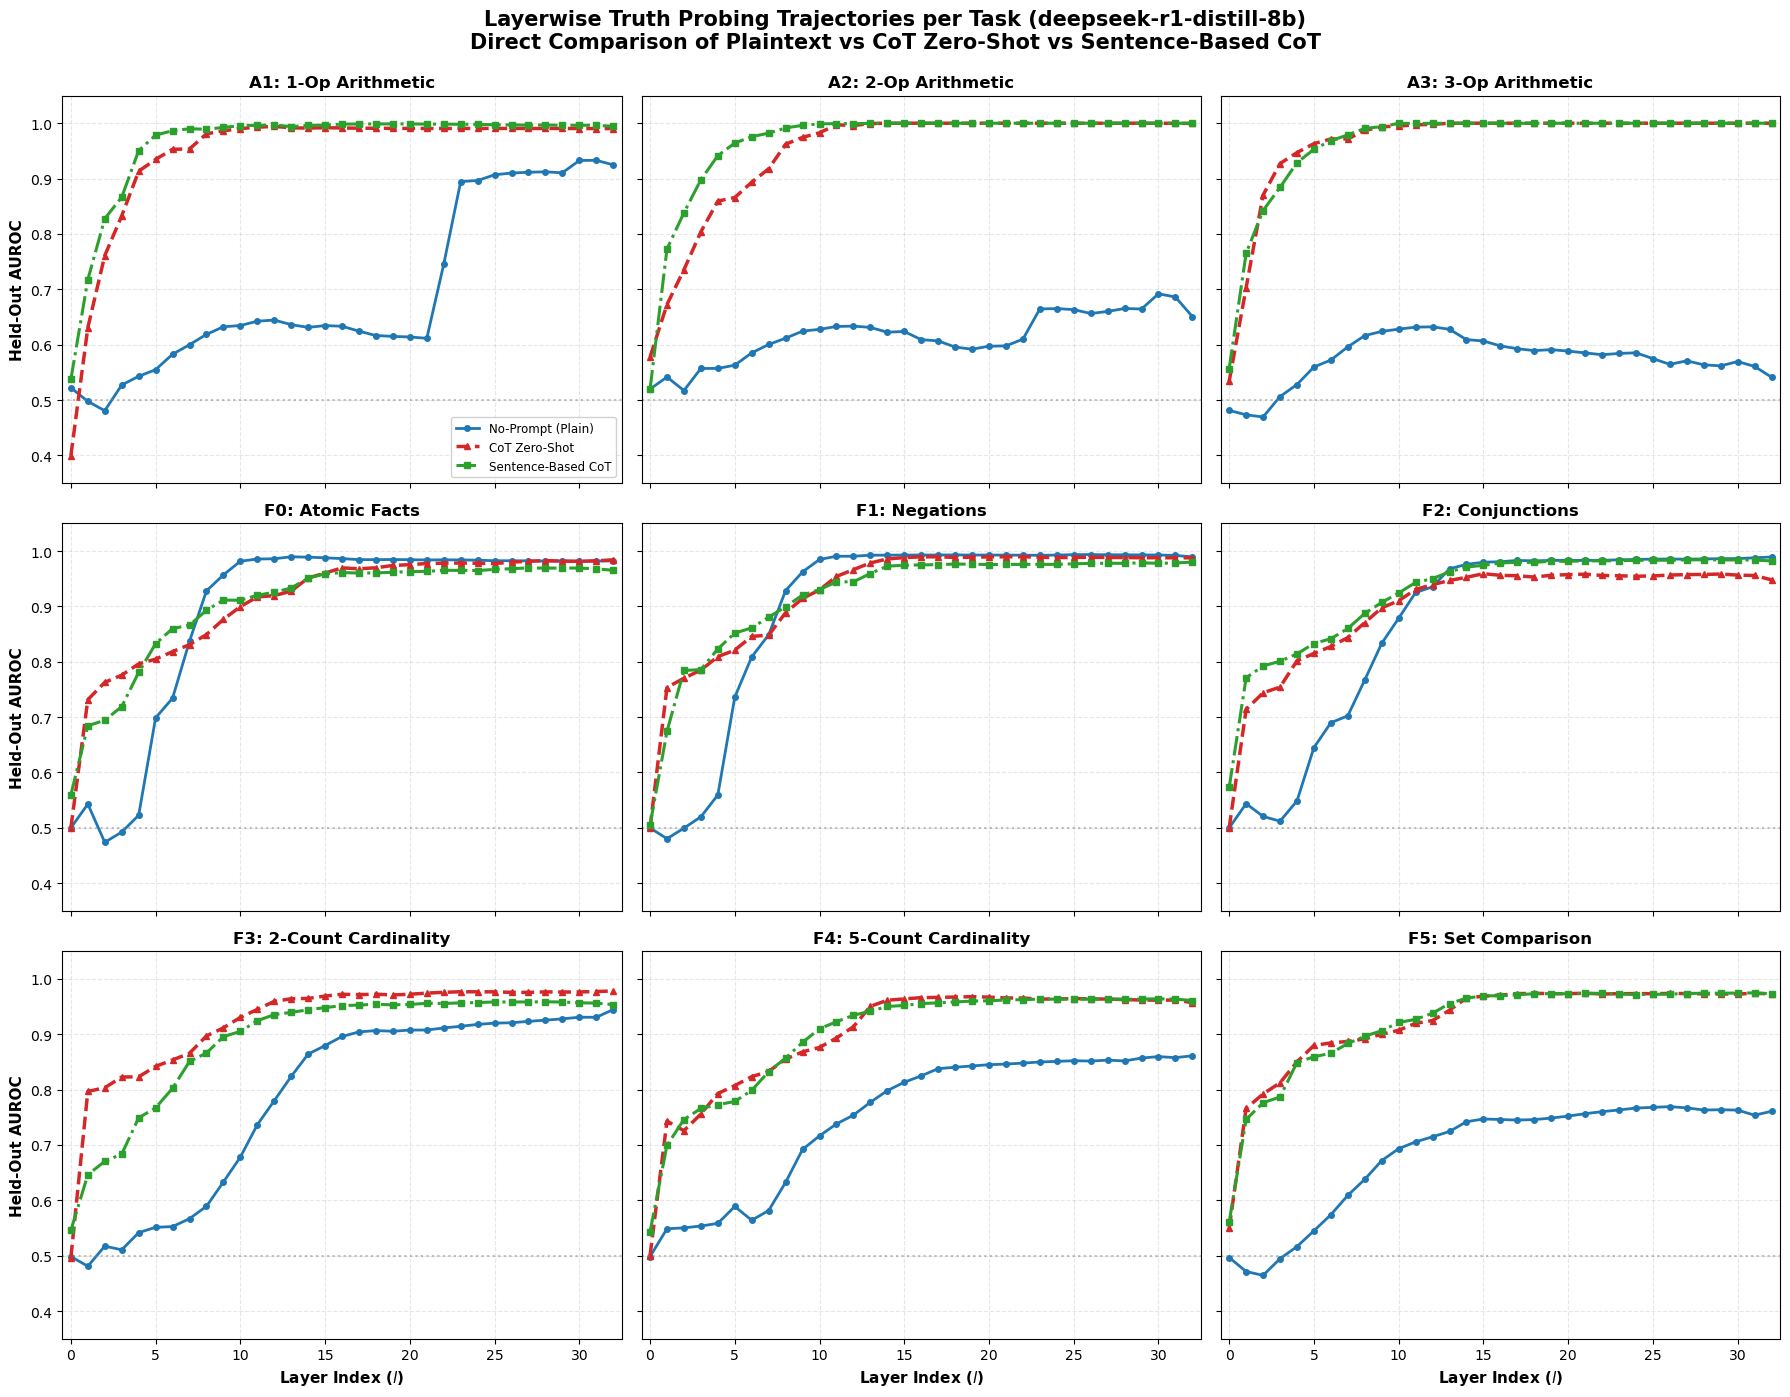

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharex=True, sharey=True)
conditions = [
    ("no-prompt", "No-Prompt (Plain)", "#1f77b4", "-", 2.0),
    ("cot-zero-shot", "CoT Zero-Shot", "#d62728", "--", 2.5),
    ("sentence-based-CoT", "Sentence-Based CoT", "#2ca02c", "-.", 2.2),
]

for idx, task in enumerate(tasks):
    ax = axes[idx // 3, idx % 3]
    task_label = STYLE_MAP[task]["label"]
    for cond_key, cond_label, color, ls, lw in conditions:
        sub = in_domain[(in_domain["train_task"] == task) & (in_domain["train_condition"] == cond_key)].sort_values("layer")
        if len(sub) > 0:
            ax.plot(sub["layer"], sub["auroc"], color=color, linestyle=ls, linewidth=lw,
                    marker="o" if ls == "-" else ("^" if ls == "--" else "s"), markersize=4, label=cond_label)
    ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
    ax.set_title(task_label, fontsize=12, fontweight="bold")
    ax.set_ylim(0.35, 1.05)
    ax.set_xlim(-0.5, 32.5)
    ax.grid(True, linestyle="--", alpha=0.3)
    if idx % 3 == 0:
        ax.set_ylabel("Held-Out AUROC", fontsize=11, fontweight="semibold")
    if idx // 3 == 2:
        ax.set_xlabel("Layer Index ($l$)", fontsize=11, fontweight="semibold")
    if idx == 0:
        ax.legend(loc="lower right", fontsize=8.5, framealpha=0.9)

plt.suptitle(f"Layerwise Truth Probing Trajectories per Task ({model_name})\nDirect Comparison of Plaintext vs CoT Zero-Shot vs Sentence-Based CoT", fontsize=15, fontweight="bold", y=0.995)
plt.tight_layout()
plt.savefig("figures/figure_2_per_task_grid.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Mechanistic Conclusions & Discussion
1. **Arithmetic Ceiling Elimination**: In the unprompted plaintext condition, multi-step arithmetic ($A_2, A_3$) plateaus at chance levels ($\text{AUROC} \approx 0.60$) due to the lack of intermediate computation tokens in residual space. CoT completely breaks this ceiling, achieving **$\text{AUROC} = 1.0000$** across all arithmetic tasks.
2. **Layer Delay / Depth Stratification**: Consistent with Poulis et al., introducing instructions and reasoning chains shifts optimal probe separability into intermediate and late layers ($l/L \in [0.45, 0.95]$), allowing truth representations to stabilize across compositional counting and reasoning domains.